<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/HRV_analisis_pryecto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea(1).png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Proyecto 1 - Análisis de la frecuencia cardíaca de sujetos con AFIB y SB entre los 60 - 69 años</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>

# Conectar con Drive y cargar el archivo Diagnostics.xlsx

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.signal
from scipy.signal import find_peaks
from scipy import signal
from scipy.stats import levene, ttest_ind, mannwhitneyu, shapiro
from google.colab import drive
from statsmodels.tsa.stattools import adfuller
import random
import os
import zipfile

In [5]:
# Carga el archivo 'Diagnostics.xlsx' desde Google Drive
diag = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Biosenales/Diagnostics.xlsx')

diag

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10641,MUSE_20181222_204306_99000,SVT,NONE,80,FEMALE,196,73,168,284,513,258,244,32,177,261,319
10642,MUSE_20181222_204309_22000,SVT,NONE,81,FEMALE,162,81,162,294,482,110,-75,27,173,254,320
10643,MUSE_20181222_204310_31000,SVT,NONE,39,MALE,152,92,152,340,540,250,38,25,208,284,378
10644,MUSE_20181222_204312_58000,SVT,NONE,76,MALE,175,178,128,310,529,98,-83,29,205,269,360


# Extraer grupo de interés

Sujetos con arritmias AFIB y SB con edades entre 60 - 69 años.

In [8]:
# Filtrar primero en diag
afib_60_69 = diag[(diag['Rhythm'] == 'AFIB') & (diag['PatientAge'].between(60, 69))]
afib_archivos = [f + '.csv' for f in afib_60_69['FileName'].tolist()]

sb_60_69 = diag[(diag['Rhythm'] == 'SB') & (diag['PatientAge'].between(60, 69))]
sb_archivos = [f + '.csv' for f in sb_60_69['FileName'].tolist()]

In [11]:
import os
import zipfile

# Crear carpetas de destino
base_extract_dir = '/content/'
sb_extract_dir = os.path.join(base_extract_dir, 'sb_60_69')
afib_extract_dir = os.path.join(base_extract_dir, 'afib_60_69')
os.makedirs(sb_extract_dir, exist_ok=True)
os.makedirs(afib_extract_dir, exist_ok=True)

# Ruta al archivo ZIP
zip_filepath = '/content/drive/MyDrive/Colab Notebooks/Biosenales/ECGDataDenoised.zip'

# Mapeo de archivos deseados y sus carpetas
desired_files = {name: sb_extract_dir for name in sb_archivos}
desired_files.update({name: afib_extract_dir for name in afib_archivos})

# Extraer los archivos desde el ZIP
with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
    for zip_info in zip_ref.infolist():
        filename = os.path.basename(zip_info.filename)
        if filename in desired_files:
            with zip_ref.open(zip_info) as source_file:
                output_path = os.path.join(desired_files[filename], filename)
                with open(output_path, 'wb') as out_file:
                    out_file.write(source_file.read())
            #rint(f"Archivo '{filename}' extraído a '{desired_files[filename]}'")
print(f"Cantidad de archivos para SB (bradicardia sinusal): {len(sb_60_69)}")
print(f"Cantidad de archivos para AFIB (fibrilación auricular): {len(afib_60_69)}")


Cantidad de archivos para SB (bradicardia sinusal): 1206
Cantidad de archivos para AFIB (fibrilación auricular): 395


# Variabilidad de la frecuencia cardiaca (HRV)

In [12]:
!pip install hrv-analysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 7.5 MB/s eta 0:00:00


In [13]:
import os
import numpy as np
import pandas as pd
from hrvanalysis import get_time_domain_features, get_frequency_domain_features
from concurrent.futures import ThreadPoolExecutor

# Rutas de las carpetas con los sujetos filtrados por edad y ritmo
afib_path = '/content/afib_60_69'
sb_path = '/content/sb_60_69'

# Función para analizar cada sujeto
def analizar_sujeto(ruta_archivo):
    try:
        rr_intervals = np.genfromtxt(ruta_archivo, delimiter=',')

        if rr_intervals.ndim > 1:
            rr_intervals = rr_intervals.flatten()
        if np.mean(rr_intervals) > 3:
            rr_intervals = rr_intervals / 1000.0

        rr_ms = rr_intervals * 1000.0
        time = get_time_domain_features(rr_ms)
        freq = get_frequency_domain_features(rr_intervals)

        return [
            os.path.splitext(os.path.basename(ruta_archivo))[0],
            time.get('sdnn', np.nan),
            time.get('rmssd', np.nan),
            freq.get('lf', np.nan) * 1000**2 if freq.get('lf') else np.nan,
            freq.get('hf', np.nan) * 1000**2 if freq.get('hf') else np.nan,
            freq.get('lf_hf_ratio', np.nan)
        ]
    except:
        return None

# Procesar AFIB y SB
def procesar_grupo(carpeta, ritmo):
    archivos = [os.path.join(carpeta, f) for f in os.listdir(carpeta) if f.endswith('.csv')]
    with ThreadPoolExecutor(max_workers=8) as executor:
        resultados = list(executor.map(analizar_sujeto, archivos))
    resultados = [r + [ritmo] for r in resultados if r is not None]
    return resultados

afib_data = procesar_grupo(afib_path, 'AFIB')
sb_data = procesar_grupo(sb_path, 'SB')

# Crear dataframe combinado
df_hrv = pd.DataFrame(afib_data + sb_data, columns=[
    'Sujeto', 'SDNN (ms)', 'RMSSD (ms)', 'LF (ms²)', 'HF (ms²)', 'LF/HF', 'Rhythm'
])

df_hrv.to_csv('/content/drive/MyDrive/hrv_afib_vs_sb_60_69.csv', index=False)


/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 14, using nperseg = 14
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 9, using nperseg = 9
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 6, using nperseg = 6
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 8, using nperseg = 8
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg

# análisis estadístico AFIB vs ST

In [14]:
import pandas as pd
from scipy.stats import kstest, zscore, ttest_ind, mannwhitneyu

# Leer datos ya procesados
df = pd.read_csv('/content/drive/MyDrive/hrv_afib_vs_sb_60_69.csv')

# Eliminar outliers con IQR
metricas = ["SDNN (ms)", "RMSSD (ms)", "LF (ms²)", "HF (ms²)", "LF/HF"]
df_filtrado = df.copy()
for m in metricas:
    Q1 = df_filtrado[m].quantile(0.25)
    Q3 = df_filtrado[m].quantile(0.75)
    IQR = Q3 - Q1
    df_filtrado = df_filtrado[(df_filtrado[m] >= Q1 - 1.5*IQR) & (df_filtrado[m] <= Q3 + 1.5*IQR)]

# Pruebas estadísticas
for metrica in metricas:
    afib_vals = df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica].dropna()
    st_vals = df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica].dropna()

    print(f"\n----- Análisis de {metrica} -----")
    print(f"H₀: No hay diferencia en {metrica} entre AFIB y SB.")
    print(f"H₁: Hay diferencia en {metrica} entre AFIB y SB.")

    # Normalidad
    afib_z = zscore(afib_vals)
    st_z = zscore(st_vals)
    p_normal_afib = kstest(afib_z, 'norm').pvalue
    p_normal_st = kstest(st_z, 'norm').pvalue
    print(f"P-valor normalidad AFIB: {p_normal_afib:.4f}")
    print(f"P-valor normalidad SB: {p_normal_st:.4f}")

    # Elegir prueba
    if p_normal_afib > 0.05 and p_normal_st > 0.05:
        test = 't-test'
        stat, p = ttest_ind(afib_vals, st_vals)
    else:
        test = 'Mann-Whitney U'
        stat, p = mannwhitneyu(afib_vals, st_vals, alternative='two-sided')

    print(f"Prueba aplicada: {test}")
    print(f"Estadístico: {stat:.4f}, p-valor: {p:.4f}")
    if p < 0.05:
        print("Conclusión: Se rechaza H₀. Diferencias significativas.\n")
    else:
        print("Conclusión: No se rechaza H₀. No hay diferencias significativas.\n")



----- Análisis de SDNN (ms) -----
H₀: No hay diferencia en SDNN (ms) entre AFIB y SB.
H₁: Hay diferencia en SDNN (ms) entre AFIB y SB.
P-valor normalidad AFIB: 0.6335
P-valor normalidad SB: 0.0015
Prueba aplicada: Mann-Whitney U
Estadístico: 123260.0000, p-valor: 0.0000
Conclusión: Se rechaza H₀. Diferencias significativas.


----- Análisis de RMSSD (ms) -----
H₀: No hay diferencia en RMSSD (ms) entre AFIB y SB.
H₁: Hay diferencia en RMSSD (ms) entre AFIB y SB.
P-valor normalidad AFIB: 0.0530
P-valor normalidad SB: 0.0002
Prueba aplicada: Mann-Whitney U
Estadístico: 118489.0000, p-valor: 0.0000
Conclusión: Se rechaza H₀. Diferencias significativas.


----- Análisis de LF (ms²) -----
H₀: No hay diferencia en LF (ms²) entre AFIB y SB.
H₁: Hay diferencia en LF (ms²) entre AFIB y SB.
P-valor normalidad AFIB: 0.0000
P-valor normalidad SB: 0.0000
Prueba aplicada: Mann-Whitney U
Estadístico: 83004.0000, p-valor: 0.1249
Conclusión: No se rechaza H₀. No hay diferencias significativas.


----- 

<ipython-input-24-1f060725219a>:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica], df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica]], labels=['AFIB', 'SB'])


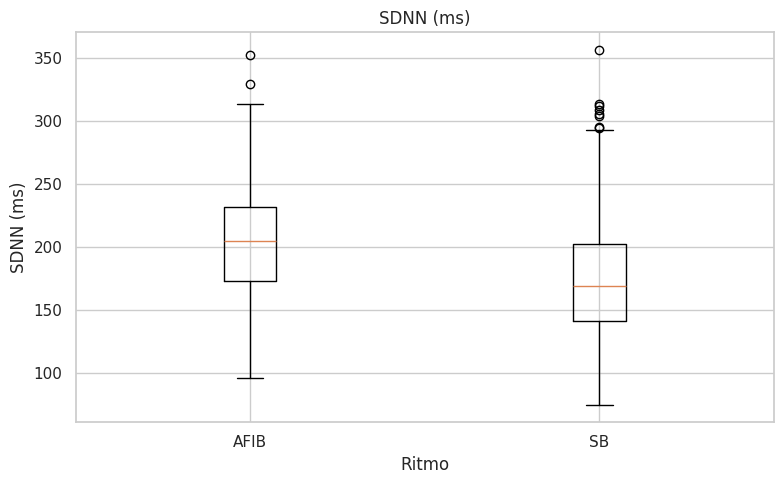

<ipython-input-24-1f060725219a>:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica], df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica]], labels=['AFIB', 'SB'])


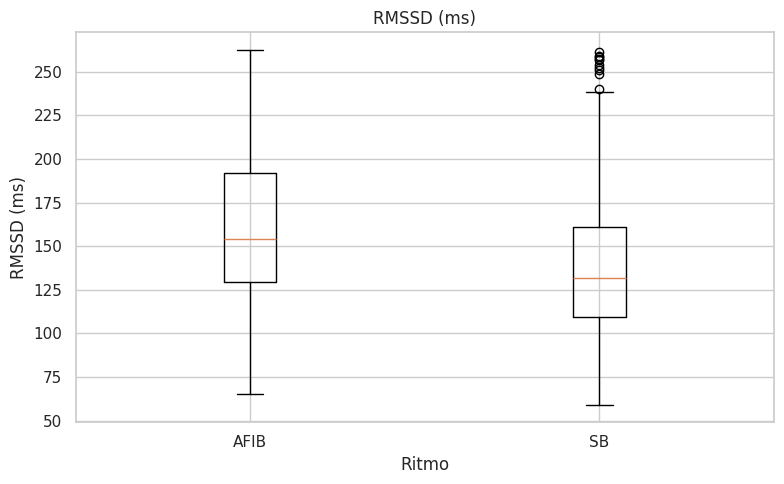

<ipython-input-24-1f060725219a>:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica], df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica]], labels=['AFIB', 'SB'])


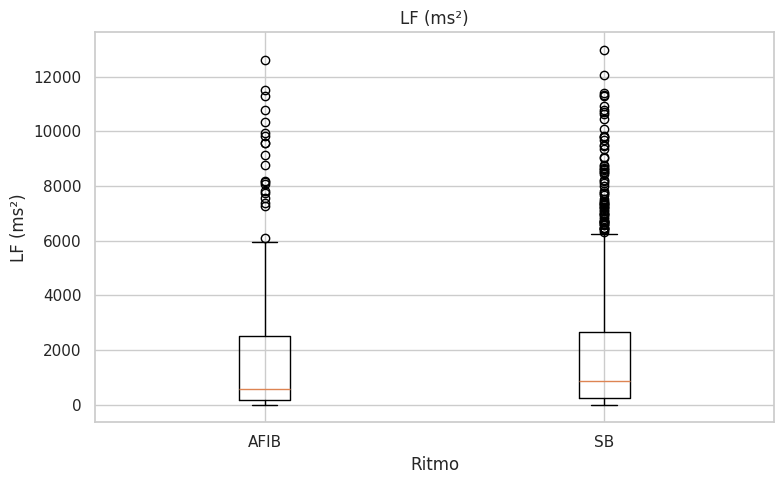

<ipython-input-24-1f060725219a>:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica], df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica]], labels=['AFIB', 'SB'])


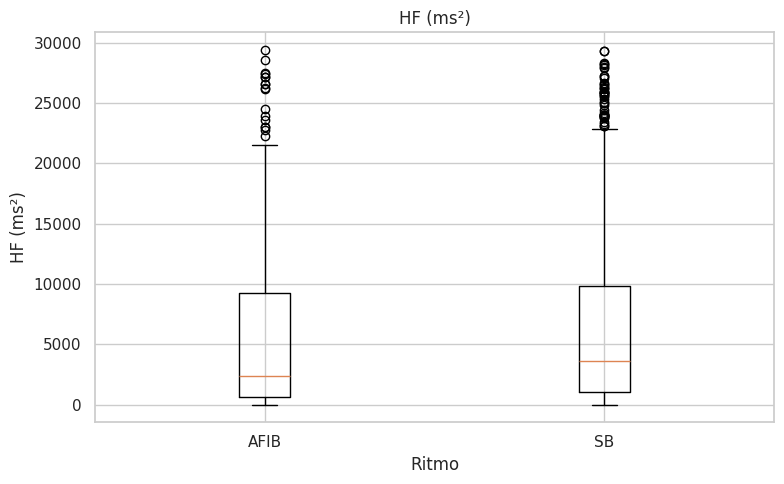

<ipython-input-24-1f060725219a>:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica], df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica]], labels=['AFIB', 'SB'])


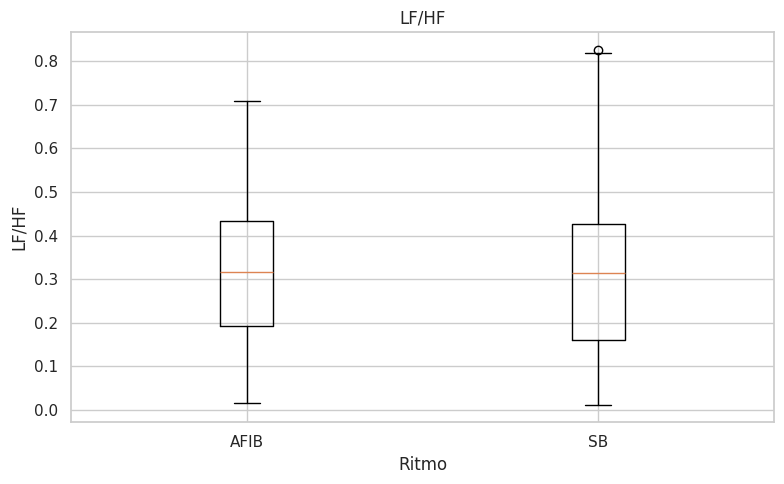

In [24]:
import seaborn as sns
# Leer los datos ya filtrados (puede ser el mismo que usaste para análisis)
df = pd.read_csv('/content/drive/MyDrive/hrv_afib_vs_sb_60_69.csv')

# Eliminar outliers (opcional, si ya lo hiciste antes puedes omitir esta parte)
metricas = ["SDNN (ms)", "RMSSD (ms)", "LF (ms²)", "HF (ms²)", "LF/HF"]
df_filtrado = df.copy()
for m in metricas:
    Q1 = df_filtrado[m].quantile(0.25)
    Q3 = df_filtrado[m].quantile(0.75)
    IQR = Q3 - Q1
    df_filtrado = df_filtrado[(df_filtrado[m] >= Q1 - 1.5*IQR) & (df_filtrado[m] <= Q3 + 1.5*IQR)]

# Estilo general
#sns.set(style="whitegrid")

# Crear boxplots para cada métrica
for metrica in metricas:
    plt.figure(figsize=(8, 5))
    #sns.boxplot(data=df_filtrado, x='Rhythm', y=metrica, palette='Set2')
    plt.boxplot([df_filtrado[df_filtrado['Rhythm'] == 'AFIB'][metrica], df_filtrado[df_filtrado['Rhythm'] == 'SB'][metrica]], labels=['AFIB', 'SB'])
    plt.title(f'{metrica} en ')
    plt.xlabel('Ritmo')
    plt.ylabel(metrica)
    plt.tight_layout()
    plt.grid(True)
    plt.show()
